In [21]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 22.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 9.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


# Fase 3 — Preparação dos Dados

Este notebook tem como objetivo preparar os dados brutos do projeto de predição de atraso de entregas da empresa fictícia NexaMarket.

Nesta etapa, serão realizadas as principais transformações necessárias para construir a base analítica de modelagem, contendo uma linha por pedido.

As principais atividades são:

- carregar os arquivos CSV;
- converter colunas de datas;
- criar a variável-alvo `atrasou_entrega`;
- agregar tabelas com múltiplas linhas por pedido;
- integrar informações de clientes, vendedores, produtos, pagamentos e geolocalização;
- criar variáveis derivadas;
- remover variáveis com risco de vazamento de dados;
- salvar a base final em `data/processed/`.

## 1. Importaçao das bibliotecas

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from math import radians, sin, cos, sqrt, atan2

Matplotlib is building the font cache; this may take a moment.


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Definição dos caminhos

In [3]:
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data' / 'raw').is_dir()
)
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'

PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)


## 3. Carregamento dos dados

In [4]:
csv_files = sorted(RAW_DATA_PATH.glob('*.csv'))
dfs = []

for file in csv_files:
    dfs.append(pd.read_csv(file))

## 4. Padronização inicial dos nomes das colunas

In [5]:
for df in dfs:
    df.columns = (df.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(" ", "_")
                ) 


## 5. Conversão das colunas de data

In [6]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

pedidos = dfs[5]

for coluna in colunas_data:
    pedidos[coluna] = pd.to_datetime(pedidos[coluna], errors="coerce")


In [7]:
itens_pedido = dfs[2]
itens_pedido["shipping_limit_date"] = pd.to_datetime(
    itens_pedido["shipping_limit_date"],
    errors="coerce"
    )

## 6. Filtragem dos pedidos entregues

Para a primeira versão da base analítica, vamos trabalhar apenas com pedidos entregues, pois precisamos conhecer o resultado final da entrega para criar a variável-alvo.

In [13]:
pedidos_entregues = pedidos[
    (pedidos["order_status"] == "delivered") &
    (pedidos["order_delivered_customer_date"].notna()) & 
    (pedidos["order_estimated_delivery_date"].notna()) &
    (pedidos["order_delivered_carrier_date"].notna())
    ].copy()

pedidos_entregues.shape


(96469, 8)

## 7. Criação da variável-alvo

In [15]:
pedidos["atrasou_entrega"] = (
    (pedidos["order_delivered_customer_date"] >
    pedidos["order_estimated_delivery_date"])
    .astype(int)
)

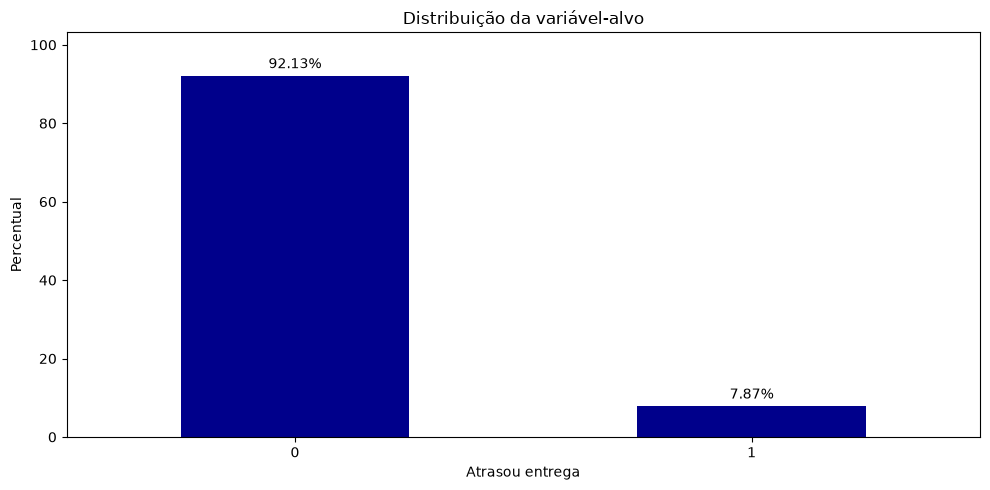

In [40]:
percentuais = pedidos["atrasou_entrega"].value_counts(normalize=True).mul(100).round(2)
ax = percentuais.plot(kind="bar", figsize=(10, 5), color="darkblue")

plt.title("Distribuição da variável-alvo")
plt.xlabel("Atrasou entrega")
plt.ylabel("Percentual")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3)
ax.set_ylim(0, percentuais.max() * 1.12)

plt.tight_layout()
plt.show()

